# Liver Fibrosis Ultrasound Classification - ResNet50

Uses preprocessed data with train/val/test splits already applied.
Groups are kept together to prevent data leakage.

In [8]:
import subprocess
import sys

try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab")
except ImportError:
    IN_COLAB = False
    print("Not running in Google Colab")

try:
    gpu_info = subprocess.check_output(['nvidia-smi'], stderr=subprocess.STDOUT).decode()
    print("NVIDIA GPU detected")
    for line in gpu_info.split('\n'):
        if 'Tesla' in line or 'NVIDIA' in line or 'GeForce' in line:
            print(f"  {line.strip()}")
            break
    HAS_GPU = True
except:
    print("No NVIDIA GPU found")
    HAS_GPU = False

print("=" * 60)

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if HAS_GPU and not torch.cuda.is_available():
    print("GPU detected but PyTorch is CPU-only")
    print("Installing PyTorch with CUDA support...")
    subprocess.check_call([sys.executable, "-m", "pip", "uninstall", "-y", "torch", "torchvision", "torchaudio"])
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "torch", "torchvision", "torchaudio",
        "--index-url", "https://download.pytorch.org/whl/cu118"
    ])
    print("Please restart the runtime and run again")

elif torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Running in Google Colab
NVIDIA GPU detected
  | NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
PyTorch version: 2.9.0+cu126
CUDA available: True
CUDA version: 12.6
GPU: Tesla T4
GPU memory: 15.8 GB


In [9]:
import os
import random
import time
import json
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets, models
from torch.cuda.amp import autocast, GradScaler

from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.9.0+cu126
CUDA available: True


## Configuration

In [10]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted


In [11]:
# BASE_DATA_DIR = Path("/content/drive/MyDrive/Data/liver")
# DATASET_PATH = BASE_DATA_DIR / "preprocessed"
DATASET_PATH = Path('/content/drive/MyDrive/local/preprocessed')


CONFIG = {
    'use_gpu': True,
    'num_workers': 4,
    'pin_memory': True,

    'batch_size': 256,

    'model_name': 'resnet50',
    'pretrained': True,
    'dropout_rate': 0.3,

    'num_epochs': 50,
    'learning_rate': 1e-4,
    'weight_decay': 1e-4,
    'warmup_epochs': 3,
    'use_amp': True,
    'grad_clip': 1.0,

    'patience': 10,

    'random_seed': 42,

    'use_class_weights': True,
}

if not DATASET_PATH.exists():
    raise FileNotFoundError(f"Dataset not found at {DATASET_PATH}")

print(f"Dataset path: {DATASET_PATH}")

device = torch.device('cuda' if (CONFIG['use_gpu'] and torch.cuda.is_available()) else 'cpu')
print(f"Using device: {device}")

if torch.cuda.is_available():
    total_memory_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {total_memory_gb:.1f} GB")
    print(f"Batch size: {CONFIG['batch_size']}")

torch.manual_seed(CONFIG['random_seed'])
random.seed(CONFIG['random_seed'])
np.random.seed(CONFIG['random_seed'])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG['random_seed'])
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Dataset path: /content/drive/MyDrive/local/preprocessed
Using device: cuda
GPU: Tesla T4
Memory: 15.8 GB
Batch size: 256


## Load Preprocessed Data

In [12]:
metadata_path = DATASET_PATH / 'metadata_summary.json'
if metadata_path.exists():
    with open(metadata_path) as f:
        metadata = json.load(f)
    print("Loaded preprocessing metadata")
    print(f"Version: {metadata.get('version', 'unknown')}")
    stats = metadata.get('statistics', {})
    print(f"Train: {stats.get('train', {}).get('images', 'N/A')} images, {stats.get('train', {}).get('groups', 'N/A')} groups")
    print(f"Val: {stats.get('val', {}).get('images', 'N/A')} images, {stats.get('val', {}).get('groups', 'N/A')} groups")
    print(f"Test: {stats.get('test', {}).get('images', 'N/A')} images, {stats.get('test', {}).get('groups', 'N/A')} groups")
else:
    print("No metadata found, will count images from directories")

Loaded preprocessing metadata
Version: 3.0
Train: 4380 images, 1075 groups
Val: 973 images, 230 groups
Test: 970 images, 231 groups


In [13]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    transforms.RandomErasing(p=0.2),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_dataset = datasets.ImageFolder(DATASET_PATH / 'train', transform=train_transform)
val_dataset = datasets.ImageFolder(DATASET_PATH / 'val', transform=eval_transform)
test_dataset = datasets.ImageFolder(DATASET_PATH / 'test', transform=eval_transform)

classes = train_dataset.classes
num_classes = len(classes)

print(f"Classes: {classes}")
print(f"Train images: {len(train_dataset)}")
print(f"Val images: {len(val_dataset)}")
print(f"Test images: {len(test_dataset)}")

Classes: ['F0', 'F1', 'F2', 'F3', 'F4']
Train images: 4556
Val images: 973
Test images: 970


In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=True,
    num_workers=CONFIG['num_workers'],
    pin_memory=CONFIG['pin_memory'],
    persistent_workers=True if CONFIG['num_workers'] > 0 else False,
    prefetch_factor=2 if CONFIG['num_workers'] > 0 else None,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=CONFIG['pin_memory'],
    persistent_workers=True if CONFIG['num_workers'] > 0 else False,
    prefetch_factor=2 if CONFIG['num_workers'] > 0 else None,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    num_workers=CONFIG['num_workers'],
    pin_memory=CONFIG['pin_memory'],
    persistent_workers=True if CONFIG['num_workers'] > 0 else False,
    prefetch_factor=2 if CONFIG['num_workers'] > 0 else None,
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 18
Val batches: 4
Test batches: 4


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


## Class Weights

In [15]:
class_counts = []
for i in range(num_classes):
    count = sum(1 for _, label in train_dataset.samples if label == i)
    class_counts.append(count)

print("Class distribution (train):")
for i, cls_name in enumerate(classes):
    percentage = (class_counts[i] / len(train_dataset)) * 100
    print(f"  {cls_name}: {class_counts[i]:4d} ({percentage:5.2f}%)")

total_samples = sum(class_counts)
class_weights = [total_samples / (num_classes * count) for count in class_counts]
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("\nClass weights:")
for i, cls_name in enumerate(classes):
    print(f"  {cls_name}: {class_weights[i]:.4f}")

Class distribution (train):
  F0: 1590 (34.90%)
  F1:  687 (15.08%)
  F2:  550 (12.07%)
  F3:  581 (12.75%)
  F4: 1148 (25.20%)

Class weights:
  F0: 0.5731
  F1: 1.3263
  F2: 1.6567
  F3: 1.5683
  F4: 0.7937


## Model

In [16]:
class ResNet50WithDropout(nn.Module):
    def __init__(self, num_classes, dropout_rate=0.3, pretrained=True):
        super().__init__()
        weights = 'DEFAULT' if pretrained else None
        self.backbone = models.resnet50(weights=weights)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

model = ResNet50WithDropout(
    num_classes=num_classes,
    dropout_rate=CONFIG['dropout_rate'],
    pretrained=CONFIG['pretrained']
)
model = model.to(device)

if CONFIG['use_class_weights']:
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
    print("Using weighted CrossEntropyLoss")
else:
    criterion = nn.CrossEntropyLoss()
    print("Using standard CrossEntropyLoss")

optimizer = optim.AdamW(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay']
)

total_steps = len(train_loader) * CONFIG['num_epochs']
warmup_steps = len(train_loader) * CONFIG['warmup_epochs']

def lr_lambda(current_step):
    if current_step < warmup_steps:
        return float(current_step) / float(max(1, warmup_steps))
    progress = float(current_step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return max(0.0, 0.5 * (1.0 + np.cos(np.pi * progress)))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler = GradScaler() if CONFIG['use_amp'] else None

print(f"Architecture: ResNet50")
print(f"Pretrained: {CONFIG['pretrained']}")
print(f"Dropout: {CONFIG['dropout_rate']}")
print(f"Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 88.3MB/s]


Using weighted CrossEntropyLoss
Architecture: ResNet50
Pretrained: True
Dropout: 0.3
Trainable params: 23,518,277


/tmp/ipython-input-3292153367.py:45: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if CONFIG['use_amp'] else None


## Training Functions

In [17]:
def train_one_epoch(model, loader, criterion, optimizer, scheduler, scaler, device, grad_clip=None):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc='Train', leave=False)
    for inputs, targets in pbar:
        inputs = inputs.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad()

        if scaler is not None:
            with autocast():
                outputs = model(inputs)
                loss = criterion(outputs, targets)

            scaler.scale(loss).backward()

            if grad_clip is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()

            if grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)

            optimizer.step()

        scheduler.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == targets).sum().item()
        total += targets.size(0)

        pbar.set_postfix(loss=running_loss/total, acc=100. * correct/total)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_targets = []
    all_preds = []
    all_probs = []

    with torch.no_grad():
        pbar = tqdm(loader, desc='Eval', leave=False)
        for inputs, targets in pbar:
            inputs = inputs.to(device, non_blocking=True)
            targets = targets.to(device, non_blocking=True)

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_loss += loss.item() * inputs.size(0)
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)

            correct += (preds == targets).sum().item()
            total += targets.size(0)

            all_targets.extend(targets.cpu().tolist())
            all_preds.extend(preds.cpu().tolist())
            all_probs.extend(probs.cpu().tolist())

    epoch_loss = running_loss / total if total > 0 else 0
    epoch_acc = correct / total if total > 0 else 0

    return epoch_loss, epoch_acc, all_targets, all_preds, all_probs

## Training Loop

In [18]:
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'lr': []
}

best_val_acc = 0.0
best_model_wts = None
epochs_without_improvement = 0

print("="*60)
print("TRAINING START")
print("="*60)
print(f"Epochs: {CONFIG['num_epochs']}")
print(f"Batch size: {CONFIG['batch_size']}")
print(f"Learning rate: {CONFIG['learning_rate']}")
print(f"Early stopping patience: {CONFIG['patience']}")
print("="*60 + "\n")

start_time = time.time()

for epoch in range(CONFIG['num_epochs']):
    print(f"Epoch {epoch+1}/{CONFIG['num_epochs']}")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, scheduler, scaler, device, CONFIG['grad_clip']
    )

    val_loss, val_acc, _, _, _ = evaluate(model, val_loader, criterion, device)

    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc*100:.2f}%")
    print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc*100:.2f}%")
    print(f"  LR: {current_lr:.6f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
        print(f"  New best model (val_acc: {val_acc*100:.2f}%)")
    else:
        epochs_without_improvement += 1
        print(f"  No improvement for {epochs_without_improvement} epoch(s)")

    if epochs_without_improvement >= CONFIG['patience']:
        print(f"\nEarly stopping after {epoch+1} epochs")
        break

    print()

total_time = time.time() - start_time
print("\n" + "="*60)
print("TRAINING COMPLETE")
print("="*60)
print(f"Total time: {total_time//60:.0f}m {total_time%60:.0f}s")
print(f"Best validation accuracy: {best_val_acc*100:.2f}%")
print("="*60)

TRAINING START
Epochs: 50
Batch size: 256
Learning rate: 0.0001
Early stopping patience: 10

Epoch 1/50


Train:   0%|          | 0/18 [00:00<?, ?it/s]/tmp/ipython-input-971531021.py:15: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:192: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


  Train - Loss: 1.5957, Acc: 22.76%
  Val   - Loss: 1.5839, Acc: 32.27%
  LR: 0.000033
  New best model (val_acc: 32.27%)

Epoch 2/50


  Train - Loss: 1.4373, Acc: 44.34%
  Val   - Loss: 1.4186, Acc: 42.86%
  LR: 0.000067
  New best model (val_acc: 42.86%)

Epoch 3/50


  Train - Loss: 1.2209, Acc: 50.59%
  Val   - Loss: 1.0328, Acc: 55.19%
  LR: 0.000100
  New best model (val_acc: 55.19%)

Epoch 4/50


...

  Train - Loss: 0.1148, Acc: 96.60%
  Val   - Loss: 1.0610, Acc: 75.23%
  LR: 0.000055
  No improvement for 6 epoch(s)

Epoch 26/50


  Train - Loss: 0.1140, Acc: 96.49%
  Val   - Loss: 1.0862, Acc: 73.79%
  LR: 0.000052
  No improvement for 7 epoch(s)

Epoch 27/50


  Train - Loss: 0.1032, Acc: 96.73%
  Val   - Loss: 0.8754, Acc: 76.46%
  LR: 0.000048
  No improvement for 8 epoch(s)

Epoch 28/50


  Train - Loss: 0.1049, Acc: 96.75%
  Val   - Loss: 0.9097, Acc: 76.46%
  LR: 0.000045
  No improvement for 9 epoch(s)

Epoch 29/50


  Train - Loss: 0.0899, Acc: 97.61%
  Val   - Loss: 0.8576, Acc: 77.39%
  LR: 0.000042
  No improvement for 10 epoch(s)

Early stopping after 29 epochs

TRAINING COMPLETE
Total time: 30m 30s
Best validation accuracy: 79.65%


## Evaluation

In [19]:
if best_model_wts is not None:
    model.load_state_dict(best_model_wts)
    print("Loaded best model weights")

val_loss, val_acc, val_targets, val_preds, val_probs = evaluate(
    model, val_loader, criterion, device
)

print(f"\nValidation Results:")
print(f"  Loss: {val_loss:.4f}")
print(f"  Accuracy: {val_acc*100:.2f}%")

Loaded best model weights



Validation Results:
  Loss: 0.5935
  Accuracy: 79.65%


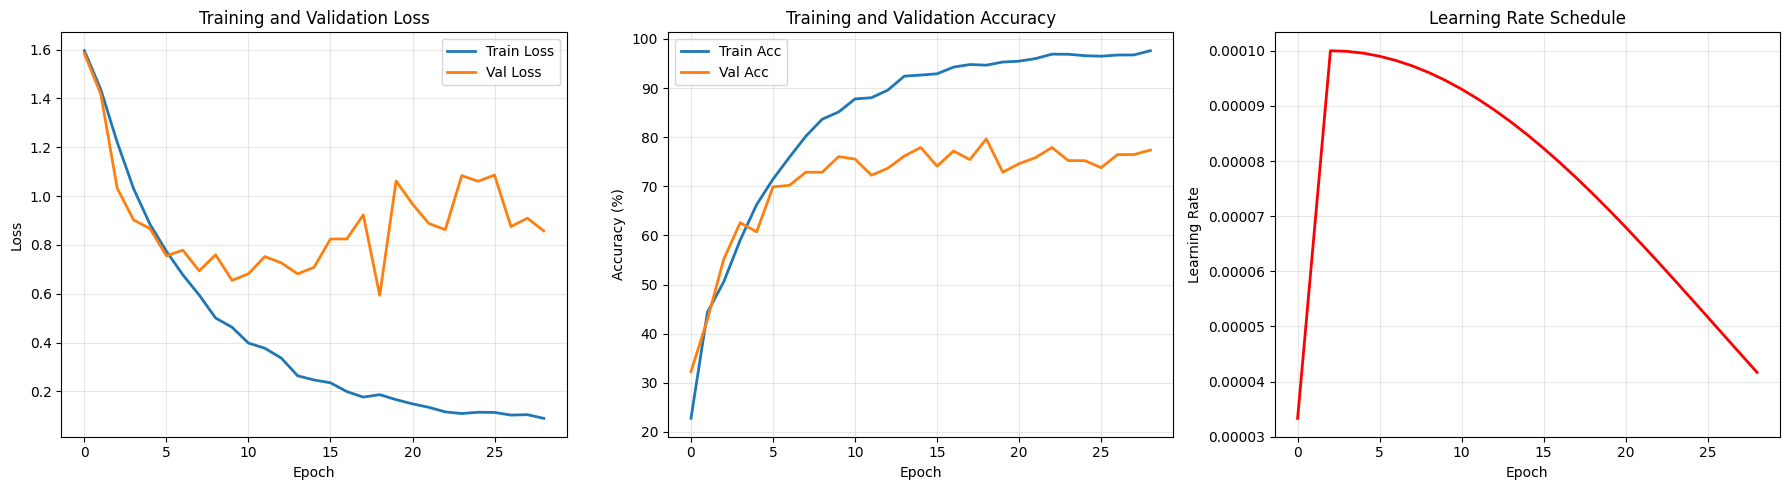

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot([x*100 for x in history['train_acc']], label='Train Acc', linewidth=2)
axes[1].plot([x*100 for x in history['val_acc']], label='Val Acc', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(history['lr'], linewidth=2, color='red')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Learning Rate')
axes[2].set_title('Learning Rate Schedule')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

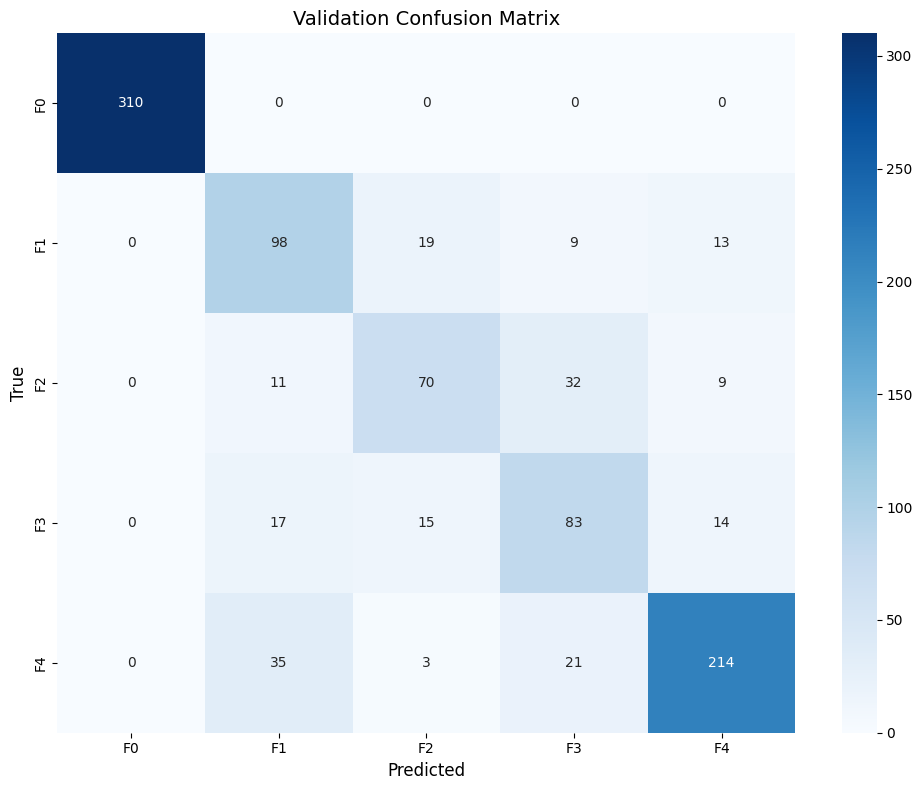


Classification Report:
              precision    recall  f1-score   support

          F0       1.00      1.00      1.00       310
          F1       0.61      0.71      0.65       139
          F2       0.65      0.57      0.61       122
          F3       0.57      0.64      0.61       129
          F4       0.86      0.78      0.82       273

    accuracy                           0.80       973
   macro avg       0.74      0.74      0.74       973
weighted avg       0.80      0.80      0.80       973



In [21]:
cm = confusion_matrix(val_targets, val_preds, labels=list(range(num_classes)))

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Validation Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(val_targets, val_preds, target_names=classes, zero_division=0))

TEST SET EVALUATION



Test Results:
  Loss: 0.7015
  Accuracy: 80.10%


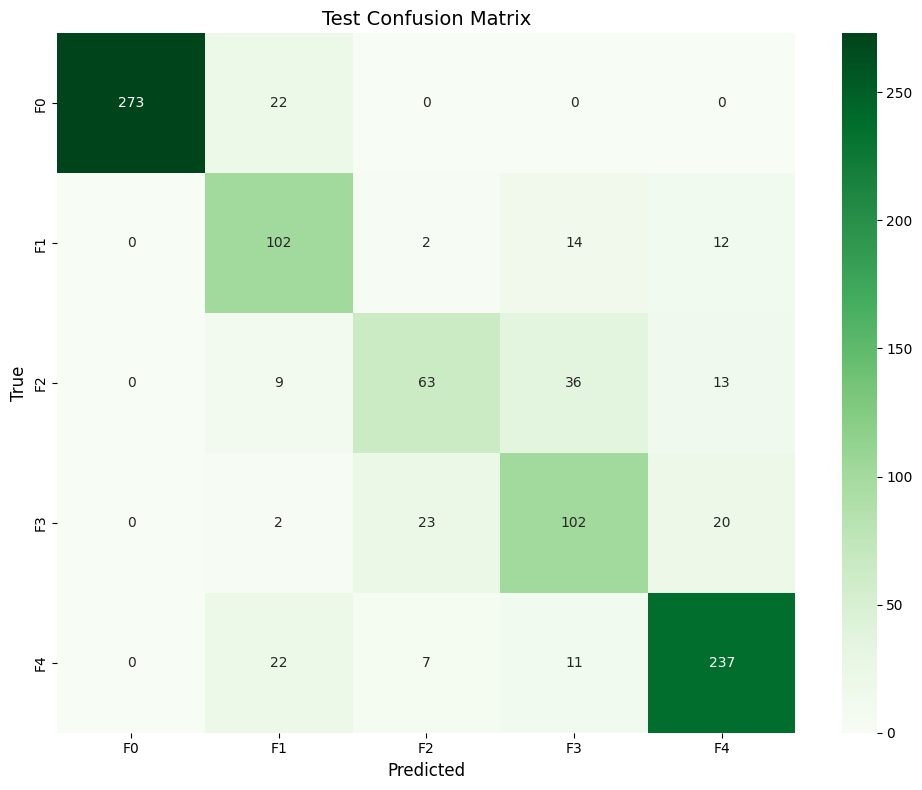


Test Classification Report:
              precision    recall  f1-score   support

          F0       1.00      0.93      0.96       295
          F1       0.65      0.78      0.71       130
          F2       0.66      0.52      0.58       121
          F3       0.63      0.69      0.66       147
          F4       0.84      0.86      0.85       277

    accuracy                           0.80       970
   macro avg       0.76      0.76      0.75       970
weighted avg       0.81      0.80      0.80       970



In [28]:
print("="*60)
print("TEST SET EVALUATION")
print("="*60)

test_loss, test_acc, test_targets, test_preds, test_probs = evaluate(
    model, test_loader, criterion, device
)

print(f"\nTest Results:")
print(f"  Loss: {test_loss:.4f}")
print(f"  Accuracy: {test_acc*100:.2f}%")
print("="*60)

test_cm = confusion_matrix(test_targets, test_preds, labels=list(range(num_classes)))

plt.figure(figsize=(10, 8))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.title('Test Confusion Matrix', fontsize=14)
plt.tight_layout()
plt.show()

print("\nTest Classification Report:")
print(classification_report(test_targets, test_preds, target_names=classes, zero_division=0))

## Save Model

In [29]:
output_dir = Path('outputs')
output_dir.mkdir(parents=True, exist_ok=True)

torch.save(model.state_dict(), output_dir / 'resnet50_state_dict.pth')
torch.save(model, output_dir / 'resnet50_full_model.pt')

training_metadata = {
    'version': '3.0',
    'config': CONFIG,
    'classes': classes,
    'num_classes': num_classes,
    'best_val_acc': float(best_val_acc),
    'test_acc': float(test_acc),
    'test_loss': float(test_loss),
    'epochs_trained': len(history['train_loss']),
    'train_images': len(train_dataset),
    'val_images': len(val_dataset),
    'test_images': len(test_dataset),
    'history': history,
    'class_weights': class_weights,
}

with open(output_dir / 'training_metadata.json', 'w') as f:
    json.dump(training_metadata, f, indent=2)

print(f"Model saved to {output_dir}/")
print(f"  - resnet50_state_dict.pth")
print(f"  - resnet50_full_model.pt")
print(f"  - training_metadata.json")
print(f"\nFinal Results:")
print(f"  - Best Val Accuracy: {best_val_acc*100:.2f}%")
print(f"  - Test Accuracy: {test_acc*100:.2f}%")

Model saved to outputs/
  - resnet50_state_dict.pth
  - resnet50_full_model.pt
  - training_metadata.json

Final Results:
  - Best Val Accuracy: 79.65%
  - Test Accuracy: 80.10%
